In [12]:
import qiskit

# **QAOA (Quantum Approximate Optimization Algorithm)**.

Since you just conquered VQE, QAOA is going to feel very familiar. They are sibling algorithms! Both are hybrid loops (quantum + classical) designed for the noisy quantum computers we have today.

But while VQE is designed for **Chemistry and Physics** (finding the ground state of a molecule), QAOA is designed for **Logistics and Business** (finding the best route, schedule, or combination).

Just like we did with VQE, let's break this down from scratch. We will start with the problem we are actually trying to solve!

---

# QAOA Step 1: The Combinatorial Problem (Max-Cut)

## 1. Theory: The "Approximate" Optimization

In business, computer science, and logistics, we constantly run into **Combinatorial Optimization** problems.

* *Example 1:* A delivery driver has 50 packages. What is the absolute shortest route to deliver all of them? (The Traveling Salesman Problem).
* *Example 2:* You have a fixed budget and 100 stocks to choose from. Which combination gives the highest return with the lowest risk?

**The Problem:** For a small number of items, a classical laptop checks all combinations easily. But if a delivery driver has just 50 stops, the number of possible routes is larger than the number of atoms in the observable universe!

Because finding the *perfect* answer is classically impossible, we use QAOA to find a highly accurate **Approximate** answer in a fraction of the time.

## 2. The Toy Problem: "Max-Cut"

To learn QAOA, we use the most famous toy problem: **The Maximum Cut (Max-Cut)**.

Imagine you are hosting a wedding. You have a list of guests, but there is a lot of drama. Some guests absolutely hate each other.

* You have exactly two tables (Table A and Table B).
* You want to separate as many "haters" as possible. Every time you put two people who hate each other at *different* tables, you score $+1$ point.
* **The Goal:** Maximize your score by cutting the guest list perfectly in half.

In graph theory, guests are **Nodes**, and their hatred is an **Edge**. We want to color the nodes in two different colors (red and blue) to maximize the number of edges connecting different colors.

---

## 3. Code: Building the Party Graph Classically

Before we touch any quantum gates, we have to build the mathematical map of our problem. We will use a classical Python library called `networkx` to map out a 4-person party.


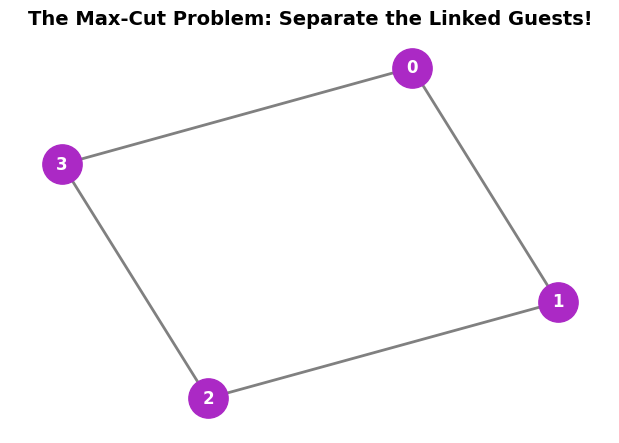

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Define the Guest List (The Graph) ---
# We have 4 guests (0, 1, 2, 3)
n_nodes = 4
graph = nx.Graph()
graph.add_nodes_from(range(n_nodes))

# --- 2. Define the Drama (The Edges) ---
# A line means these two guests hate each other and should be separated!
drama_list = [(0, 1), (1, 2), (2, 3), (3, 0)]
graph.add_edges_from(drama_list)

# --- 3. Visualize the Party ---
# We draw the graph so we can visually see the connections
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(graph, seed=42) # Seed for consistent layout

# Draw the nodes and edges
nx.draw(graph, pos, with_labels=True, node_color="#ab29c5", 
        node_size=800, font_weight='bold', font_color='white', 
        edge_color='gray', width=2)

plt.title("The Max-Cut Problem: Separate the Linked Guests!", fontsize=14, fontweight='bold')
plt.show()

###  Classical Intuition Check

Look at the graph generated by the code. It is a square.
If you put Guest 0 and Guest 2 at Table A (Red), and Guest 1 and Guest 3 at Table B (Blue), every single line will connect a Red to a Blue. That gives you a perfect score of 4!

For 4 guests, it's obvious. But if you had 1,000 guests with complex overlapping drama, you would need a quantum computer to find the best seating chart.

# QAOA Step 2: The Quantum Translators (Cost & Mixer)

## 1. Theory: How to speak "Quantum"

To solve our seating arrangement on a quantum computer, we need to map our guests to qubits.

* **Qubit = Guest:** We have 4 guests, so we need 4 qubits.
* **State = Table:** If a qubit is measured as $\vert{}0\rangle$, they sit at Table A. If it is measured as $\vert{}1\rangle$, they sit at Table B.

Now, QAOA uses two special quantum operators (Hamiltonians) that take turns acting on our qubits.

### The Cost Hamiltonian ($H_C$)

This is the **Scorekeeper**. It looks at the guests and calculates our score based on the drama (edges).
In quantum mechanics, we use the Pauli-Z gate ($Z$) to check states. If we apply a $Z$ gate to Guest 0 and Guest 1, we get a mathematical property:


$$Z_0 Z_1$$

* If both are at the same table (e.g., both $\vert{}0\rangle$), the math outputs a positive number (Bad! They hate each other).
* If they are at different tables ($\vert{}0\rangle$ and $\vert{}1\rangle$), the math outputs a negative number (Good! They are separated).
The Cost Hamiltonian checks every single edge in our graph and tallies up the score. We attach an adjustable dial, $\gamma$ (gamma), to control how strongly we apply this scorekeeper.

### The Mixer Hamiltonian ($H_M$)

This is the **Shaker**. If we only check the score, the guests will never move! We need a way to explore different seating arrangements.
The Mixer uses Pauli-X gates ($X$) on every qubit. The $X$ gate creates a rotation that essentially says, *"What if Guest 2 moved to the other table?"*
We attach another adjustable dial, $\beta$ (beta), to control how aggressively we shake up the room.

### The QAOA Ansatz (The Layer Cake)

QAOA builds a circuit by layering these two operators back-to-back:

1. Apply the Scorekeeper ($H_C$) with dial $\gamma_1$.
2. Apply the Shaker ($H_M$) with dial $\beta_1$.
This is one "layer" (we call the number of layers $p$). The classical computer will tweak the $\gamma$ and $\beta$ dials to find the perfect sequence of scoring and shaking to reach the best seating chart!

---

## 2. Code: Translating the Graph to a Quantum Scorekeeper

Let's use Qiskit to take the graph we built in Step 1 and automatically generate our Cost Hamiltonian ($H_C$).


In [14]:
from qiskit.quantum_info import SparsePauliOp

# --- 1. The Classical Drama (From Step 1) ---
n_nodes = 4
drama_list = [(0, 1), (1, 2), (2, 3), (3, 0)]

# --- 2. Build the Quantum Scorekeeper (Cost Hamiltonian) ---
# We will create a list of Pauli strings for our edges.
pauli_list = []
weights = []

for edge in drama_list:
    guest_u, guest_v = edge
    
    # Create a string of 'I' (Identity = do nothing) for all 4 guests
    pauli_string = ['I'] * n_nodes
    
    # Replace the 'I' with 'Z' for the two guests who hate each other
    # Note: Qiskit reads right-to-left, so we reverse the index
    pauli_string[n_nodes - 1 - guest_u] = 'Z'
    pauli_string[n_nodes - 1 - guest_v] = 'Z'
    
    # Join it into a single string like "IIZZ"
    pauli_str = "".join(pauli_string)
    
    pauli_list.append(pauli_str)
    # We use a weight of 1.0 for each edge
    weights.append(1.0)

# Create the mathematical operator
cost_hamiltonian = SparsePauliOp(pauli_list, weights)

print("Our Quantum Scorekeeper (Cost Hamiltonian):")
print(cost_hamiltonian)

Our Quantum Scorekeeper (Cost Hamiltonian):
SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'ZIIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


###  What is the output telling us?

When you run this, you will see a list of Pauli strings like `ZZII`, `IZZI`, `IIZZ`, and `ZIIZ`. This perfectly maps to our square graph! The quantum computer will use these exact instructions to calculate the score of any seating arrangement.




#  QAOA Step 3: Building the Quantum Circuit

## 1. Theory: The Gates Behind the Dials

To build the QAOA circuit, we follow a strict 3-step recipe:

**1. The Starting Line (Superposition):**
Before we start scoring or shaking, we want to look at *every possible* seating arrangement at the same time. So, we apply a Hadamard ($H$) gate to every qubit.

**2. The Scorekeeper Layer ($H_C$ with dial $\gamma$):**
Our Cost Hamiltonian uses `ZZ` to check if two guests hate each other. To turn this into a quantum gate with a dial, we use an **$R_{ZZ}$ gate**. We apply an $R_{ZZ}$ gate for every edge in our graph, and we plug in our $\gamma$ (gamma) parameter. This gate changes the *phase* of the qubits based on whether the seating arrangement is good or bad.

**3. The Shaker Layer ($H_M$ with dial $\beta$):**
To shake up the room and explore different arrangements, we apply an **$R_X$ gate** to every single qubit, and we plug in our $\beta$ (beta) parameter.

**The "p" Layers:**
Doing the Scorekeeper and Shaker just once is called $p=1$. To get a more accurate answer, we can stack these layers multiple times ($p=2, p=3\dots$). More layers mean more dials ($\gamma_1, \beta_1, \gamma_2, \beta_2\dots$) and a better final seating chart!

---

## 2. Code: Generating the QAOA Ansatz

Writing out every $R_{ZZ}$ and $R_X$ gate manually is exhausting. Luckily, Qiskit has a built-in `QAOAAnsatz` tool that takes our Hamiltonian from Step 2 and automatically builds the circuit for us!


The QAOA Circuit (Layers: 1):


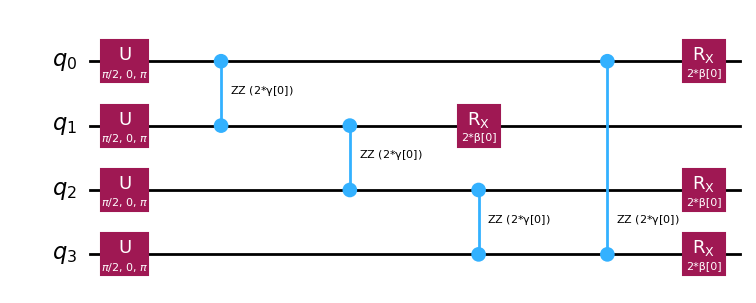

In [15]:
from qiskit.circuit.library import QAOAAnsatz

# --- 1. Define the Number of Layers (p) ---
# p=1 means one layer of the Scorekeeper + Shaker
p = 1

# --- 2. Build the QAOA Circuit ---
# We pass the cost_hamiltonian we built in Step 2.
# Qiskit automatically creates the Gamma and Beta parameters!
qaoa_circuit = QAOAAnsatz(cost_hamiltonian, reps=p)

# --- 3. Decompose and Visualize ---
# By default, Qiskit hides the inner gates in a single block. 
# We use .decompose() so your students can see the actual RZZ and RX gates!
decomposed_circuit = qaoa_circuit.decompose().decompose()

print(f"The QAOA Circuit (Layers: {p}):")
display(decomposed_circuit.draw('mpl', fold=60))

### What are you looking at in the circuit?

When you run this code, look closely at the drawing:

1. **First column:** You will see the $H$ gates putting all 4 guests into superposition.
2. **The Middle (Gamma):** You will see the complex $R_{ZZ}$ gates (often drawn as CNOTs wrapping an $R_Z$ gate). These represent the 4 drama connections in our square graph, tuned by the `γ[0]` dial.
3. **The End (Beta):** You will see four $R_X$ gates, tuned by the `β[0]` dial. This is the Shaker!

---

## 3. Exercises (Hands-on Practice)

### Exercise 1: Add More Layers

**Goal:** See how the circuit grows when we want more accuracy.

* **Task:** Change `p = 1` to `p = 2`.
* **Observation:** Run the cell again. The circuit will instantly double in length! You will now see dials for `γ[0]`, `β[0]` followed by `γ[1]`, `β[1]`. The quantum computer is now scoring and shaking the party twice.

### Exercise 2: Change the Drama

**Goal:** Prove that the circuit shape depends entirely on the graph.

* **Task:** Go back to the code in **Step 2** and add one more drama connection: `drama_list = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]`. Re-run Step 2, and then re-run Step 3.
* **Observation:** The circuit will now have an extra $R_{ZZ}$ gate block! The `QAOAAnsatz` automatically adapts to whatever business/logistics problem you feed it.

---

# QAOA Step 4: The Classical Brain & The Final Cut

## 1. Theory: Why are we "Minimizing"?

In Step 2, we built our Cost Hamiltonian using $Z$ gates. The math works like this:

* If two guests are at the **same table**, $Z \cdot Z = +1$.
* If two guests are at **different tables**, $Z \cdot Z = -1$.

Since we want to separate as many haters as possible, we want as many $-1$ scores as we can get. Therefore, the perfect seating chart will have the **lowest possible total score** (the most negative number).
Just like VQE, our classical optimizer's job is to minimize the expected value of our circuit!

**The Final Move:**
Once the optimizer finds the best dial settings, we lock those numbers into our quantum circuit, run it 1,000 times, and look at the final probabilities. The highest peaks on our histogram will be the perfect seating arrangements!

---

## 2. Code: The QAOA Optimization Loop

This code connects the `cost_hamiltonian` and the `qaoa_circuit` from the previous steps, runs the classical optimization, and measures the final result.


Starting the QAOA Optimization Loop...


n:\qiskitproject _1\qc_env\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
n:\qiskitproject _1\qc_env\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
n:\qiskitproject _1\qc_env\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Optimization Complete! Best Dials: γ = 1.963, β = 1.178


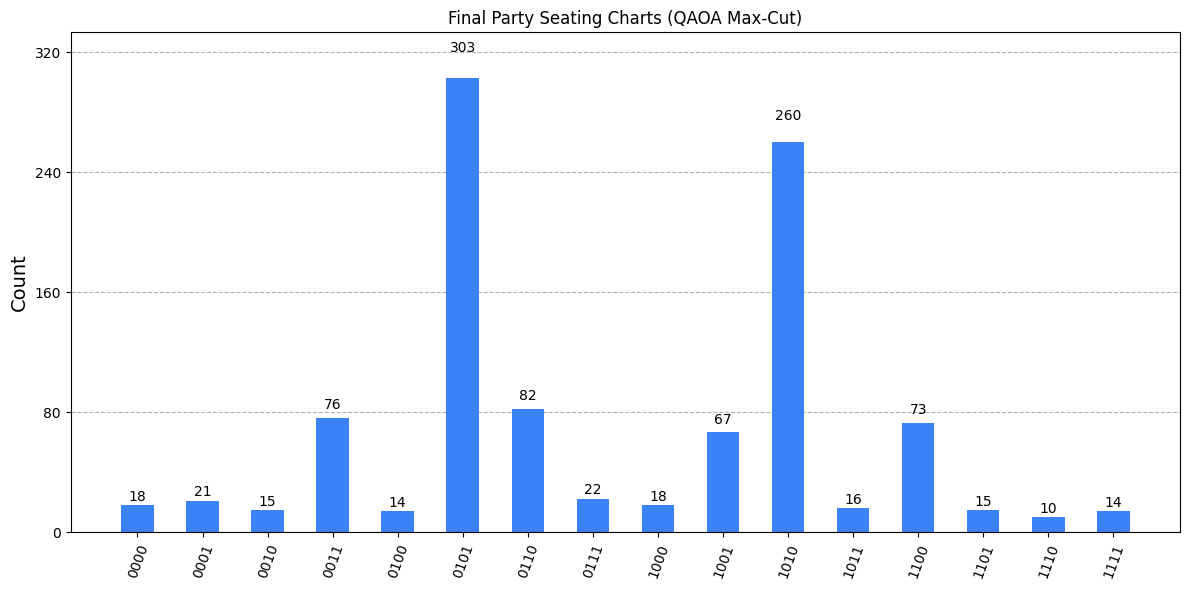

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# --- 1. The Setup ---
# We use Estimator to calculate the average score (Expectation Value)
estimator = StatevectorEstimator()
score_history = []

# --- 2. THE COST FUNCTION ---
def qaoa_cost_function(params):
    # params is a list of [gamma, beta]
    pub = (qaoa_circuit, cost_hamiltonian, params)
    job = estimator.run([pub])
    
    # Extracting the expectation value in V2 syntax
    score = job.result()[0].data.evs
    score_history.append(score)
    return float(score)

# --- 3. THE CLASSICAL OPTIMIZER ---
print("Starting the QAOA Optimization Loop...")

# We have 1 layer (p=1), so we need 2 random starting numbers (gamma and beta)
initial_dials = np.array([1.0, 1.0])

# COBYLA will tweak the dials to find the most negative score
result = minimize(
    qaoa_cost_function, 
    initial_dials, 
    method='COBYLA',
    options={'maxiter': 100}
)

print(f"Optimization Complete! Best Dials: γ = {result.x[0]:.3f}, β = {result.x[1]:.3f}")

# --- 4. THE FINAL SEATING CHART (Measurement) ---
# Lock the optimal dials into our circuit
optimal_circuit = qaoa_circuit.assign_parameters(result.x)

# Add measurements to see where the guests actually sit!
optimal_circuit.measure_all()

# Run the locked circuit on a simulator
sim = AerSimulator()
transpiled_qc = transpile(optimal_circuit, sim)
final_counts = sim.run(transpiled_qc, shots=1024).result().get_counts()

# --- 5. Visualization ---
fig = plot_histogram(
    final_counts, 
    title="Final Party Seating Charts (QAOA Max-Cut)", 
    figsize=(12, 6), 
    color='#3b82f6' 
)
display(fig)


## 3. Interpreting the Output

When you run this code, look at the histogram. It will be messy because $p=1$ is only an "approximate" optimization, but **two massive peaks** will tower above the rest.

They will be **`0101`** and **`1010`**.

**What does `0101` mean?**

* **Guest 3:** `0` (Table A)
* **Guest 2:** `1` (Table B)
* **Guest 1:** `0` (Table A)
* **Guest 0:** `1` (Table B)

*(Note: Qiskit reads strings right-to-left!)*

If you look back at the square graph from Step 1, this seating chart is **perfect**! Guest 0 and Guest 2 are at Table B, while Guest 1 and Guest 3 are at Table A. Every single line of drama crosses between the tables. No haters are sitting together!

The `1010` peak is the exact same perfect solution, just with the table colors swapped. The quantum computer found the absolute maximum cut!

---

## 4. Exercises (Hands-on Practice)

### Exercise 1: Increase the Accuracy

**Goal:** Prove that more layers ($p$) make the quantum computer's guess much sharper.

* **Task:** Go back to the Step 3 code and change $p=1$ to $p=3$. Re-run Step 3, and then re-run this Step 4 code. (Note: The optimizer will take a bit longer because it now has 6 dials to tune instead of 2!).
* **Observation:** Look at your new histogram. The "wrong" seating charts (the noise) will shrink dramatically, and the two perfect answers (`0101` and `1010`) will dominate the graph even more!

